# 🏆 VLM: Usage
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://drive.google.com/file/d/1oTRGVAbx3zY8M9Kau8xqIvxjLr1QbIsq/view?usp=sharing)

## Introduction

### 📌 What are Vision Language Models & How do they work?

Vision language models are multimodal AI systems built by combining a large language model (LLM) with a vision encoder, giving the LLM the ability to **“see.”**

Most VLMs follow an architecture with three parts (as shown in the image below):

- A vision encoder is a transformer architecture that has been trained on millions of image-text pairs, giving it the ability to associate images and text.
- A projector is a set of layers that translates the output of the vision encoder into a form the LLM can understand, often interpreted as image tokens.
- An LLM, which can be any LLM that has already been trained and released.

<p align="center" >
  <img src="https://www.nvidia.com/en-us/glossary/vision-language-models/_jcr_content/root/responsivegrid/nv_container_copy_co_300503066/nv_image.coreimg.svg/1736168815674/vlm-architecture-diagram.svg" width="500" title="VLM Components"/>
</p>

### 📌 What Are the Capabilities of Vision-Language Models?
VLM can perform various tasks such as chatting about images, image recognition via instructions, visual question answering, document understanding, and more — some of which we'll explore in this challenge.
The image below showcases the different tasks a VLM can perform.


<p align="center" >
  <img src="https://cdn.prod.website-files.com/6479eab6eb2ed5e597810e9e/67ed59567624cf7b802b88a2_6687a8f8ecade4efd45a3cf6_Vision%2520Model_fig1.png" width="700" title="VLM Components"/>
</p>

Alright, enough talk — let’s mess around with these VLMs and see what they do! 🤖🎉

## Use Cases of VLMs

### Environment setup

In [1]:
!pip install transformers qwen-vl-utils -q
!pip install yt-dlp --upgrade -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 38.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 56.2 MB/s eta 0:00:00


In [2]:
!nvidia-smi

Sat May 16 15:48:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# After you finish testing each VLM, we will use the following function to free up GPU memory and remove variables from the global scope
import gc
import time
import torch

def clear_memory():
    # Delete variables if they exist in the current global scope
    if "inputs" in globals():
        del globals()["inputs"]
    if "model" in globals():
        del globals()["model"]
    if "processor" in globals():
        del globals()["processor"]
    time.sleep(2)

    # Garbage collection and clearing CUDA memory
    gc.collect()
    time.sleep(2)
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    time.sleep(2)
    gc.collect()
    time.sleep(2)

    print(f"GPU allocated memory: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
    print(f"GPU reserved memory: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

### 1. Visual Question Answering
- Goal: Answer questions about an image or video.
- Input: Image or video + a natural language question
- Output: Short natural language answer

We'll use `Qwen2-VL-2B-Instruct`.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

system
You are a helpful assistant.
user
What do you see in the image?
assistant
The image shows a dish with a reddish-brown ceramic bowl containing a stew or stewed meat dish. The dish is topped with dark purple prunes and small, brown nuts. There is also a piece of bread visible in the background. The setting appears to be a table with a purple tablecloth.


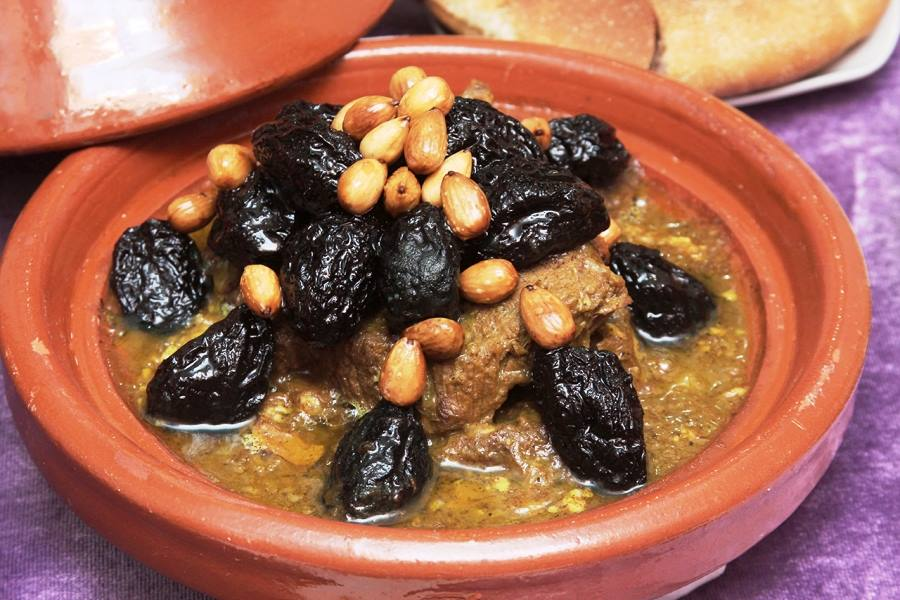

In [4]:
from PIL import Image
import requests
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor

model = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct", torch_dtype="auto", device_map="auto"
)
processor = AutoProcessor.from_pretrained("Qwen/Qwen2-VL-2B-Instruct")

# Image (try other images!)
url = "https://visitruralmorocco.com/wp-content/uploads/2023/07/tajine-5.jpg"
image = Image.open(requests.get(url, stream=True).raw)

# Question (try in Darija!)
text_query = "What do you see in the image?"

conversation = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": text_query}]}]
text_prompt = processor.apply_chat_template(conversation, add_generation_prompt=True)
inputs = processor(text=text_prompt, images=image, return_tensors="pt").to("cuda")

output = model.generate(**inputs, max_new_tokens=128)
print(processor.decode(output[0], skip_special_tokens=True))
image


#### Let's test with videos

In [5]:
import yt_dlp
from qwen_vl_utils import process_vision_info

# Download a short YouTube video
def download_video(url, out="/content/video.mp4"):
    with yt_dlp.YoutubeDL({'outtmpl': out, 'format': 'best'}) as ydl:
        ydl.download([url])

download_video("https://www.youtube.com/shorts/po8D2FUCtu0")

# Run inference on the video
video = "/content/video.mp4"
text_query = "What do you see in the video?"

messages = [{"role": "user", "content": [
    {"type": "video", "video": video, "max_pixels": 360 * 420, "fps": 1.0},
    {"type": "text", "text": text_query},
]}]

text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(text=[text], images=image_inputs, videos=video_inputs,
                   padding=True, return_tensors="pt").to("cuda")

generated_ids = model.generate(**inputs, max_new_tokens=128)
generated_ids_trimmed = [o[len(i):] for i, o in zip(inputs.input_ids, generated_ids)]
print("\n==> MODEL RESPONSE : ", processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True)[0])


[youtube] Extracting URL: https://www.youtube.com/shorts/po8D2FUCtu0
[youtube] po8D2FUCtu0: Downloading webpage


[youtube] po8D2FUCtu0: Downloading android vr player API JSON
[info] po8D2FUCtu0: Downloading 1 format(s): 18
[download] Destination: /content/video.mp4
[download] 100% of  622.51KiB in 00:00:00 at 6.59MiB/s   


qwen-vl-utils using torchcodec to read video.



==> MODEL RESPONSE :  In the video, a man is holding a bucket filled with blue liquid. He talks to the camera and then throws the bucket into the air.


In [6]:
clear_memory()

GPU allocated memory: 0.01 GB
GPU reserved memory: 4.12 GB


### 2. Image Captioning

- Goal: Generate a sentence that describes the entire image.
- Input: An image
- Output: A natural language description

Unlike VQA, which answers specific questions, image captioning gives a general overview of the image.
We'll use `blip-image-captioning-base`.

In [7]:
import torch, requests
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base", torch_dtype=torch.float16
).to("cuda")

img_url = 'https://storage.googleapis.com/sfr-vision-language-research/BLIP/demo.jpg'
raw_image = Image.open(requests.get(img_url, stream=True).raw).convert('RGB')

# Conditional: guide the caption with a prefix
inputs = processor(raw_image, "a photography of", return_tensors="pt").to("cuda", torch.float16)
print("\n===> Conditional:", processor.decode(model.generate(**inputs)[0], skip_special_tokens=True))

# Unconditional: free caption
inputs = processor(raw_image, return_tensors="pt").to("cuda", torch.float16)
print("\n===> Unconditional:", processor.decode(model.generate(**inputs)[0], skip_special_tokens=True))


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic


===> Conditional: a photography of a woman and her dog on the beach

===> Unconditional: a woman sitting on the beach with her dog


In [8]:
clear_memory()

GPU allocated memory: 0.01 GB
GPU reserved memory: 4.12 GB


### 3. OCR (Optical Character Recognition)
- Goal: Extract text from images (printed, handwritten, or scene text).
- Input: An image with optional prompts like “Extract the invoice number.”
- Output: Transcribed, machine-readable text.

We'll use `Qwen2-VL-OCR-2B-Instruct`.

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/4.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/572 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/408 [00:00<?, ?B/s]


====> MODEL RESPONSE:  
The name of the invoice sender is Ted's Small Business.<|im_end|>


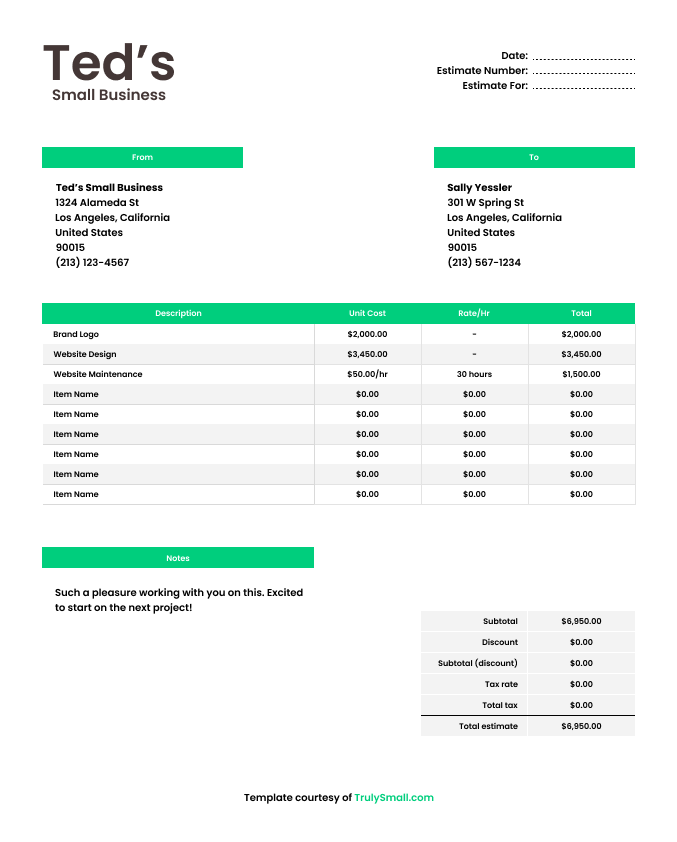

In [9]:
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info

model = Qwen2VLForConditionalGeneration.from_pretrained(
    "prithivMLmods/Qwen2-VL-OCR-2B-Instruct", torch_dtype="auto", device_map="auto"
)
processor = AutoProcessor.from_pretrained("prithivMLmods/Qwen2-VL-OCR-2B-Instruct")

url = "https://trulysmall.com/wp-content/uploads/2023/04/Simple-Invoice-Template.png"
image = Image.open(requests.get(url, stream=True).raw)
text_query = "What is the name of the invoice sender?"

messages = [{"role": "user", "content": [{"type": "image", "image": image}, {"type": "text", "text": text_query}]}]

text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(text=[text], images=image_inputs, videos=video_inputs, padding=True, return_tensors="pt").to("cuda")

output = model.generate(**inputs, max_new_tokens=128)
print("\n====> MODEL RESPONSE: ", processor.batch_decode(output, skip_special_tokens=True)[0].split("<|im_start|>assistant")[1])
image


In [10]:
clear_memory()

GPU allocated memory: 0.01 GB
GPU reserved memory: 4.12 GB


### 4. Visual Grounding
- Goal: Locate objects or regions in an image based on a text query.
- Input: An image and a natural language instruction (e.g., “Find the red car”).
- Output:

  - Bounding Box (e.g., [x_min, y_min, x_max, y_max]), or

  - Segmentation Mask, or

  - Object Label (e.g., “cat”, “tree”).

We'll use `microsoft/kosmos-2-patch14-224` for this task.

In [1]:
!pip install "transformers<5.0"

import requests

from PIL import Image
from transformers import AutoProcessor, AutoModelForVision2Seq

# First, let's load the model and its processor
model = AutoModelForVision2Seq.from_pretrained("microsoft/kosmos-2-patch14-224", device_map="auto")
processor = AutoProcessor.from_pretrained("microsoft/kosmos-2-patch14-224")

# let's define a function to run a prompt.

def run_example(prompt, image):

    inputs = processor(text=prompt, images=image, return_tensors="pt")
    inputs = inputs.to("cuda")
    generated_ids = model.generate(
      pixel_values=inputs["pixel_values"],
      input_ids=inputs["input_ids"],
      attention_mask=inputs["attention_mask"],
      image_embeds=None,
      image_embeds_position_mask=inputs["image_embeds_position_mask"],
      use_cache=True,
      max_new_tokens=128,
    )
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    _processed_text = processor.post_process_generation(generated_text, cleanup_and_extract=False)
    processed_text, entities = processor.post_process_generation(generated_text)

    return processed_text, entities

/usr/local/lib/python3.12/dist-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/6.66G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/534 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

In [2]:
# Let's define a function to draw the bounding boxes returned by the VLM.
# REMARK >> (IT'S A QUITE LONG FUNCTION NO NEED TO UNDERSTAND EVERY DETAIL, Haha!)

import cv2
import numpy as np
import os
import requests
import torch
import torchvision.transforms as T

from PIL import Image


def is_overlapping(rect1, rect2):
    x1, y1, x2, y2 = rect1
    x3, y3, x4, y4 = rect2
    return not (x2 < x3 or x1 > x4 or y2 < y3 or y1 > y4)


def draw_entity_boxes_on_image(image, entities, save_path=None):
    """_summary_
    Args:
        image (_type_): image or image path
        collect_entity_location (_type_): _description_
    """
    if isinstance(image, Image.Image):
        image_h = image.height
        image_w = image.width
        image = np.array(image)[:, :, [2, 1, 0]]
    elif isinstance(image, str):
        if os.path.exists(image):
            pil_img = Image.open(image).convert("RGB")
            image = np.array(pil_img)[:, :, [2, 1, 0]]
            image_h = pil_img.height
            image_w = pil_img.width
        else:
            raise ValueError(f"invaild image path, {image}")
    elif isinstance(image, torch.Tensor):
        image_tensor = image.cpu()
        reverse_norm_mean = torch.tensor([0.48145466, 0.4578275, 0.40821073])[:, None, None]
        reverse_norm_std = torch.tensor([0.26862954, 0.26130258, 0.27577711])[:, None, None]
        image_tensor = image_tensor * reverse_norm_std + reverse_norm_mean
        pil_img = T.ToPILImage()(image_tensor)
        image_h = pil_img.height
        image_w = pil_img.width
        image = np.array(pil_img)[:, :, [2, 1, 0]]
    else:
        raise ValueError(f"invaild image format, {type(image)} for {image}")

    if len(entities) == 0:
        return image

    new_image = image.copy()
    previous_bboxes = []
    # size of text
    text_size = 1
    # thickness of text
    text_line = 1  # int(max(1 * min(image_h, image_w) / 512, 1))
    box_line = 3
    (c_width, text_height), _ = cv2.getTextSize("F", cv2.FONT_HERSHEY_COMPLEX, text_size, text_line)
    base_height = int(text_height * 0.675)
    text_offset_original = text_height - base_height
    text_spaces = 3

    for entity_name, (start, end), bboxes in entities:
        for (x1_norm, y1_norm, x2_norm, y2_norm) in bboxes:
            orig_x1, orig_y1, orig_x2, orig_y2 = int(x1_norm * image_w), int(y1_norm * image_h), int(x2_norm * image_w), int(y2_norm * image_h)
            # draw bbox
            # random color
            color = tuple(np.random.randint(0, 255, size=3).tolist())
            new_image = cv2.rectangle(new_image, (orig_x1, orig_y1), (orig_x2, orig_y2), color, box_line)

            l_o, r_o = box_line // 2 + box_line % 2, box_line // 2 + box_line % 2 + 1

            x1 = orig_x1 - l_o
            y1 = orig_y1 - l_o

            if y1 < text_height + text_offset_original + 2 * text_spaces:
                y1 = orig_y1 + r_o + text_height + text_offset_original + 2 * text_spaces
                x1 = orig_x1 + r_o

            # add text background
            (text_width, text_height), _ = cv2.getTextSize(f"  {entity_name}", cv2.FONT_HERSHEY_COMPLEX, text_size, text_line)
            text_bg_x1, text_bg_y1, text_bg_x2, text_bg_y2 = x1, y1 - (text_height + text_offset_original + 2 * text_spaces), x1 + text_width, y1

            for prev_bbox in previous_bboxes:
                while is_overlapping((text_bg_x1, text_bg_y1, text_bg_x2, text_bg_y2), prev_bbox):
                    text_bg_y1 += (text_height + text_offset_original + 2 * text_spaces)
                    text_bg_y2 += (text_height + text_offset_original + 2 * text_spaces)
                    y1 += (text_height + text_offset_original + 2 * text_spaces)

                    if text_bg_y2 >= image_h:
                        text_bg_y1 = max(0, image_h - (text_height + text_offset_original + 2 * text_spaces))
                        text_bg_y2 = image_h
                        y1 = image_h
                        break

            alpha = 0.5
            for i in range(text_bg_y1, text_bg_y2):
                for j in range(text_bg_x1, text_bg_x2):
                    if i < image_h and j < image_w:
                        if j < text_bg_x1 + 1.35 * c_width:
                            # original color
                            bg_color = color
                        else:
                            # white
                            bg_color = [255, 255, 255]
                        new_image[i, j] = (alpha * new_image[i, j] + (1 - alpha) * np.array(bg_color)).astype(np.uint8)

            cv2.putText(
                new_image, f"  {entity_name}", (x1, y1 - text_offset_original - 1 * text_spaces), cv2.FONT_HERSHEY_COMPLEX, text_size, (0, 0, 0), text_line, cv2.LINE_AA
            )
            # previous_locations.append((x1, y1))
            previous_bboxes.append((text_bg_x1, text_bg_y1, text_bg_x2, text_bg_y2))

    pil_image = Image.fromarray(new_image[:, :, [2, 1, 0]])
    if save_path:
        pil_image.save(save_path)

    return pil_image # new_image

Describe this image in detail: A snowman wearing a hat is sitting in a snow-covered forest. He is surrounded by snow and a dark background.
[('a hat', (49, 54), [(0.546875, 0.015625, 0.734375, 0.140625)])]


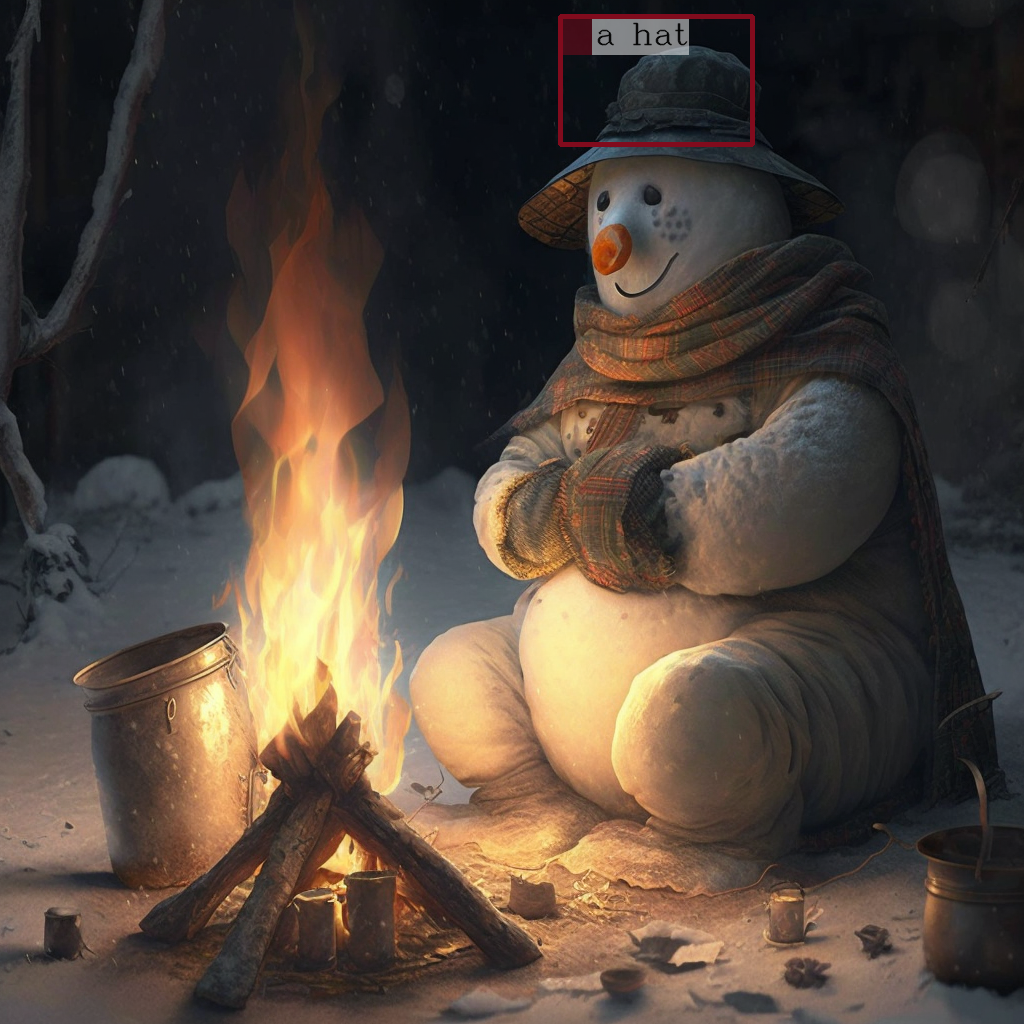

In [3]:
url = "https://huggingface.co/microsoft/kosmos-2-patch14-224/resolve/main/snowman.png"
image = Image.open(requests.get(url, stream=True).raw)

prompt = "<grounding> Describe this image in detail:"
model_output, entities = run_example(prompt, image)

new_image = draw_entity_boxes_on_image(image, entities)
print(model_output, entities, sep="\n")
new_image


## Example of VLM Datasets

Here are examples of datasets for each task above:

- Visual Question Answering (VQA): [DOC-VQA](https://huggingface.co/datasets/cmarkea/doc-vqa) – is a multilingual (English & French) visual question answering (VQA) dataset focused on document images.

- Image Captioning: [MS COCO Captions](https://huggingface.co/datasets/clip-benchmark/wds_mscoco_captions) – A dataset with images and captions for each image.

- Optical Character Recognition (OCR): [OCR-VQA](https://huggingface.co/datasets/howard-hou/OCR-VQA/viewer/default/train?row=0) – designed for OCR-based VQA. It focuses on understanding and answering questions about text present in images, particularly book covers.

- Visual Grounding: [Flickr30k_Grounding_Som](https://huggingface.co/datasets/Rajarshi-Roy-research/Flickr30k_Grounding_Som/viewer/default/train?row=4&views%5B%5D=train) – Links phrases in image captions to corresponding regions in the image with bounding boxes.

## Challenge

- **What other vision-language tasks can you think of?**
(Think about how VLMs could be applied in new or unusual ways.)

**Good luck with the rest of the challenge—and HAVE FUN! 🚀**
____